In [ ]:
vg_path = "all_annotations/scene_graphs_preprocessv1.json"
vg_img_path = "datasets/VG_100K/"
coco_path = "all_annotations/COCO (pseudo)/RLIPv2_train2017_threshold20_Tagger2_Noi24_20e_Xattnmask_SceneGraph_model_large_caption_nucleus10_thre05.json"

coco_img_path = "datasets/coco/coco/"

import json

with open(coco_path, 'r') as f:
    data = json.load(f)

In [ ]:
# pip install accelerate
import torch
from PIL import Image
from transformers import Blip2Processor, Blip2ForConditionalGeneration
import torch
from transformers import BitsAndBytesConfig

# get the corresponding img
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

# processor = Blip2Processor.from_pretrained("Salesforce/blip2-opt-2.7b")
# model = Blip2ForConditionalGeneration.from_pretrained("Salesforce/blip2-opt-2.7b", torch_dtype=torch.float16, device_map="cuda")

# processor = Blip2Processor.from_pretrained("Salesforce/blip2-flan-t5-xxl")
# model = Blip2ForConditionalGeneration.from_pretrained("Salesforce/blip2-flan-t5-xxl", torch_dtype=torch.float16, device_map="cuda")

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16
)

from transformers import pipeline

model_id = "llava-hf/llava-1.5-7b-hf"

pipe = pipeline("image-to-text", model=model_id, model_kwargs={"quantization_config": quantization_config})


3
56


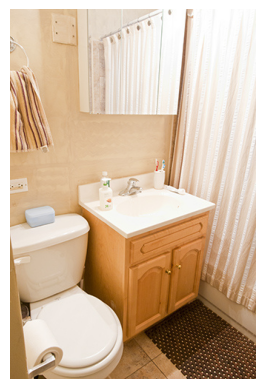

In [114]:
# get a random img id
while True:
    img = random.choice(data)
    if len(img['relationships']) > 0:
        break
img_id = img['image_id']
# put a lot of 0 in front of the id such that the total length is 12
img_id = str(img_id).zfill(12)
split = img['data_split']

data_path = coco_img_path + split

# get corresponding img path
img_path = os.path.join(data_path, str(img_id) + ".jpg")

# get all objects pairs that intersect
objects = []
for obj in img['objects']:
    bbox = [obj['x'], obj['y'], obj['w'], obj['h']]
    objects.append({'bbox': bbox, 'label': obj['names']})

# compute intersection
def intersection(bbox1, bbox2):
    x1, y1, w1, h1 = bbox1
    x2, y2, w2, h2 = bbox2

    x = max(x1, x2)
    y = max(y1, y2)
    w = min(x1 + w1, x2 + w2) - x
    h = min(y1 + h1, y2 + h2) - y

    # return boolean
    return w > 0 and h > 0

# compute intersection for all pairs
pairs = []
for i in range(len(objects)):
    for j in range(i+1, len(objects)):
        if i == j:
            continue
        if intersection(objects[i]['bbox'], objects[j]['bbox']):
            pairs.append((objects[i], objects[j]))

print(len(pairs))
print(len(objects)*(len(objects)-1))
img = Image.open(img_path)

# show image
plt.imshow(img)
plt.axis('off')
plt.show()

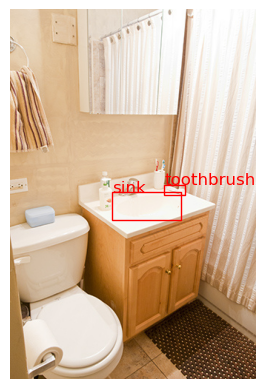

8


In [121]:
# get a random pair
pair = random.choice(pairs)

# draw bounding boxes of the pair on the image
fig, ax = plt.subplots(1)
ax.imshow(img)

for obj in pair:
    x, y, w, h = obj['bbox']
    rect = patches.Rectangle((x, y), w, h, linewidth=1, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    ax.text(x, y, obj['label'], color='r', fontsize=12)

plt.imshow(img)
plt.axis('off')
plt.show()

print(len(objects))

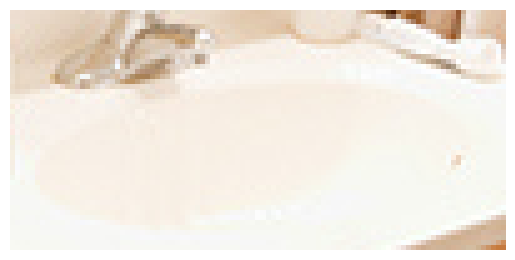

In [122]:
# get the union of the pair and crop the image
x1, y1, w1, h1 = pair[0]['bbox']
x2, y2, w2, h2 = pair[1]['bbox']

x = min(x1, x2)
y = min(y1, y2)
w = max(x1 + w1, x2 + w2) - x
h = max(y1 + h1, y2 + h2) - y

img_cropped = img.crop((x, y, x+w, y+h))

# show crop image
# show img without the ticks
plt.imshow(img_cropped)
plt.axis('off')
plt.show()

In [123]:
# generate text
prompt = "What is the relation between the "+pair[0]['label']+" and the "+pair[1]['label']+"?"

max_new_tokens = 20
prompt = "USER: <image>\n"+prompt+"\nASSISTANT:"

outputs = pipe(img, prompt=prompt, generate_kwargs={"max_new_tokens": max_new_tokens})
print(outputs[0]["generated_text"])

prompt = "What is the relation between the "+pair[1]['label']+" and the "+pair[0]['label']+"?"

prompt = "USER: <image>\n"+prompt+"\nASSISTANT:"

outputs = pipe(img, prompt=prompt, generate_kwargs={"max_new_tokens": max_new_tokens})
print(outputs[0]["generated_text"])

USER:  
What is the relation between the toothbrush and the sink?
ASSISTANT: The toothbrush is placed next to the sink, indicating that it is a common area for
USER:  
What is the relation between the sink and the toothbrush?
ASSISTANT: The sink is located next to the toothbrush, which is placed on the counter. This


In [108]:
# generate text
prompt = "Evaluate the correcteness of the following assertion: the "+pair[0]['label']+" is below the "+pair[1]['label']+". Answer by yes or no."

max_new_tokens = 20
prompt = "USER: <image>\n"+prompt+"\nASSISTANT:"

outputs = pipe(img_cropped, prompt=prompt, generate_kwargs={"max_new_tokens": max_new_tokens})
print(outputs[0]["generated_text"])

USER:  
Evaluate the correcteness of the following assertion: the person is below the surfboard. Answer by yes or no.
ASSISTANT: Yes
